In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

import nltk
from nltk.corpus import stopwords

from src.config import TWEETS_CSV
from src.data.preprocess import preprocess_series, clean_text
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [76]:
import nltk
nltk.download("stopwords")

STOPWORDS = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\srida\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [77]:
df = pd.read_csv(TWEETS_CSV)
df.head()

,id,keyword,location,text,target
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11370 entries, 0 to 11369
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        11370 non-null  int64 
 1   keyword   11370 non-null  object
 2   location  7952 non-null   object
 3   text      11370 non-null  object
 4   target    11370 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 444.3+ KB


In [80]:
df.describe(include="all")

,id,keyword,location,text,target
count,11370.000000,11370,7952,11370,11370.000000
unique,NaN,219,4504,11223,NaN
top,NaN,thunderstorm,United States,I want to help you with my project to save the...,NaN
freq,NaN,93,96,3,NaN
mean,5684.500000,NaN,NaN,NaN,0.185928
std,3282.380615,NaN,NaN,NaN,0.389066
min,0.000000,NaN,NaN,NaN,0.000000
25%,2842.250000,NaN,NaN,NaN,0.000000
50%,5684.500000,NaN,NaN,NaN,0.000000
75%,8526.750000,NaN,NaN,NaN,0.000000


In [81]:
df.isna().sum()

id             0
keyword        0
location    3418
text           0
target         0
dtype: int64

In [82]:
df["keyword"] = df["keyword"].fillna("unknown")
df["location"] = df["location"].fillna("unknown")
df.isna().sum()

id          0
keyword     0
location    0
text        0
target      0
dtype: int64

In [83]:
df["text_len"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().apply(len)

df[["text_len", "word_count"]].describe()

,text_len,word_count
count,11370.000000,11370.000000
mean,107.571944,17.166139
std,30.135399,5.510808
min,5.000000,1.000000
25%,94.000000,14.000000
50%,119.000000,18.000000
75%,126.000000,21.000000
max,149.000000,32.000000


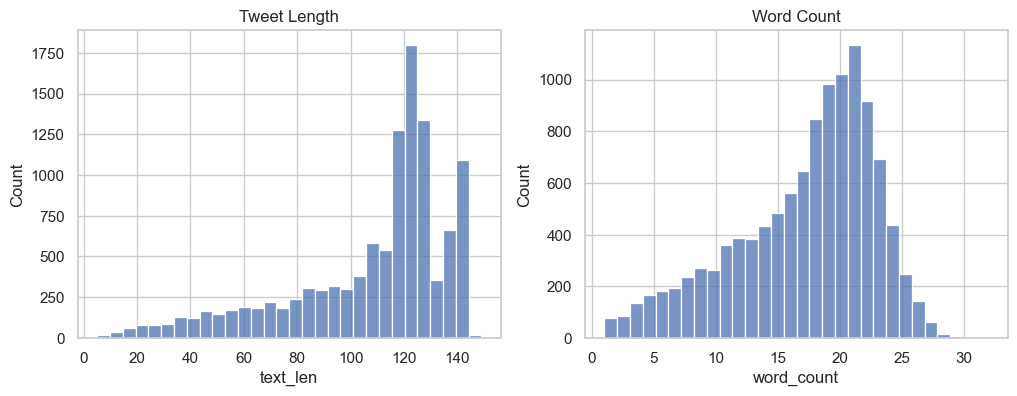

In [84]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df["text_len"], bins=30)
plt.title("Tweet Length")

plt.subplot(1,2,2)
sns.histplot(df["word_count"], bins=30)
plt.title("Word Count")

plt.show()

In [85]:
Q1 = df["text_len"].quantile(0.25)
Q3 = df["text_len"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
upper_bound

174.0

In [86]:
(df["text_len"] > upper_bound).sum()

0

In [87]:
df["text_len_capped"] = df["text_len"].clip(upper=upper_bound)

In [88]:
df["num_hashtags"] = df["text"].str.count("#")
df["num_mentions"] = df["text"].str.count("@")
df["num_urls"] = df["text"].str.count("http")

df.head()

,id,keyword,location,text,target,text_len,word_count,text_len_capped,num_hashtags,num_mentions,num_urls
0,0,ablaze,unknown,"Communal violence in Bhainsa, Telangana. ""Ston...",1,125,19,125,0,0,0
1,1,ablaze,unknown,Telangana: Section 144 has been imposed in Bha...,1,131,23,131,0,0,0
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1,63,7,63,0,0,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1,87,8,87,0,0,2
4,4,ablaze,unknown,"""Lord Jesus, your love brings freedom and pard...",0,140,23,140,0,0,1


In [89]:
df["clean_text"] = preprocess_series(df["text"])
df[["text", "clean_text"]].head()

,text,clean_text
0,"Communal violence in Bhainsa, Telangana. ""Ston...",communal violence bhainsa telangana stones pel...
1,Telangana: Section 144 has been imposed in Bha...,telangana section imposed bhainsa january clas...
2,Arsonist sets cars ablaze at dealership https:...,arsonist sets cars ablaze dealership
3,Arsonist sets cars ablaze at dealership https:...,arsonist sets cars ablaze dealership
4,"""Lord Jesus, your love brings freedom and pard...",lord jesus love brings freedom pardon fill hol...


In [ ]:
from sklearn.model_selection import train_test_split

FEATURES = ["clean_text", "text_len_capped", "word_count", "num_hashtags", "num_mentions", "num_urls"]
TARGET = "target"

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

X_train.shape, X_test.shape

((9096, 6), (2274, 6))

In [ ]:
text_col = "clean_text"
num_cols = ["text_len_capped", "word_count", "num_hashtags", "num_mentions", "num_urls"]

preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=20000, ngram_range=(1,2)), text_col),
        ("num", StandardScaler(), num_cols)
    ]
)

clf = LogisticRegression(max_iter=1000, class_weight="balanced")

model = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", clf)
])

In [92]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [93]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8478452066842568

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.87      0.90      1851
           1       0.57      0.75      0.65       423

    accuracy                           0.85      2274
   macro avg       0.75      0.81      0.77      2274
weighted avg       0.87      0.85      0.86      2274



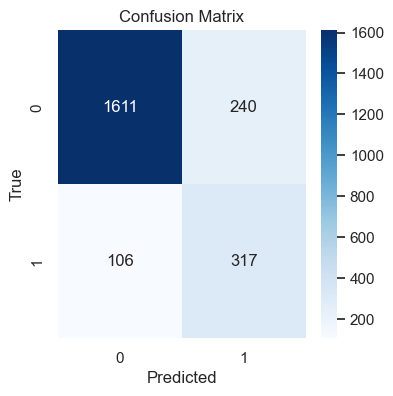

In [94]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()